---
<a id='ejercicios'></a>
# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

---
## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.


N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000
PASO 1 — OUTLIERS EN ESCALA ORIGINAL
IQR: 13 outliers (7.2%)
Z-Mod: 13 outliers (7.2%)
Límite sup IQR: $12,851
Mediana: $4,030
PASO 2 — TRANSFORMACIONES
Mediana referencia (no-ceros): $4,381
PASO 3: Skewness por transformación
Original : 4.522
√x       : 3.300
arcsinh  : 2.321
log1p    : -2.411
La transformación arcsinh es la mejor y log(x+1) mostró sobre-compresión de la cola generando asimetría negativa.


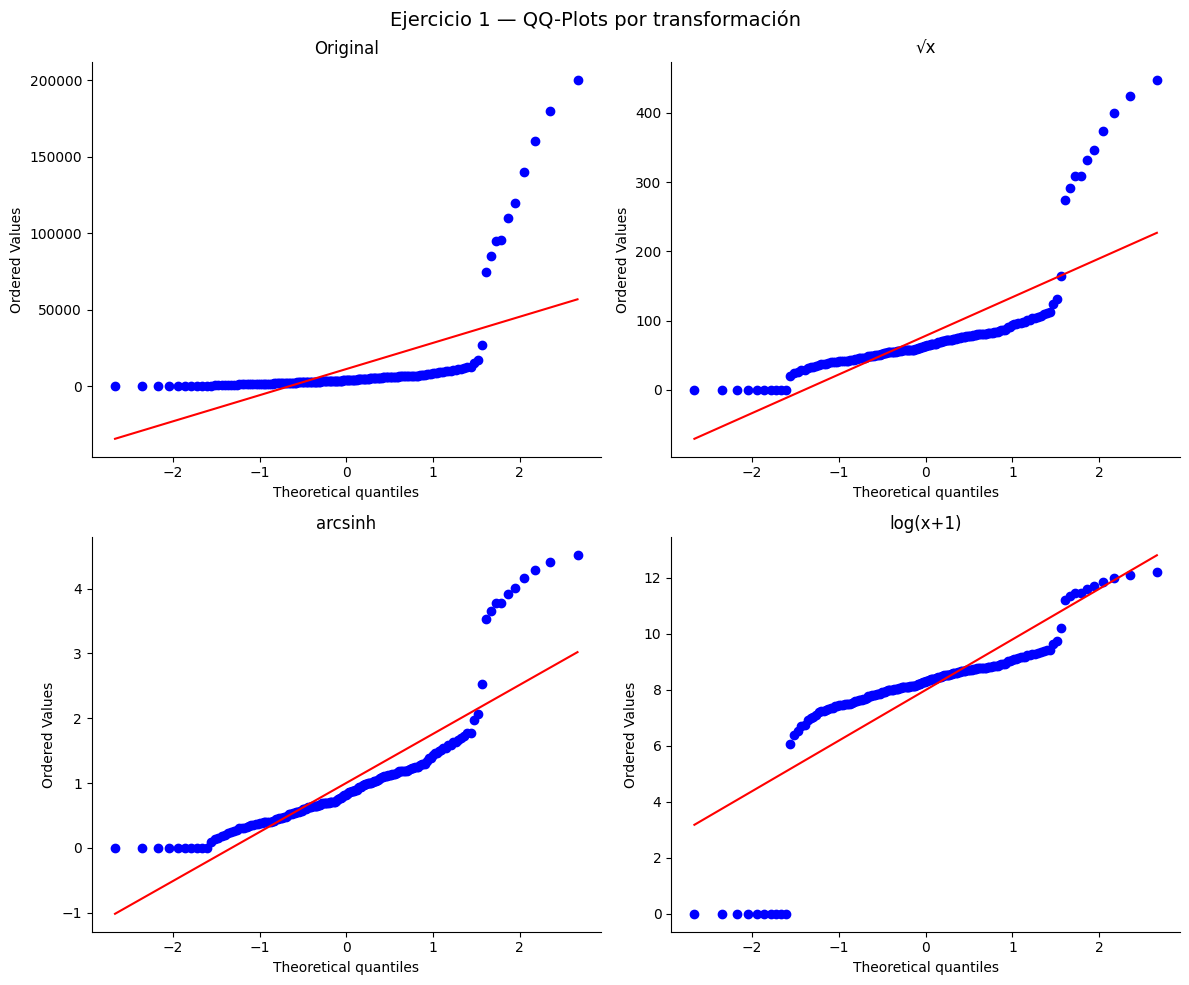

como dije anteriormente; arcsinh es la mejor se puede observar que la transformación se aproxima mejor a la distribución normal, es el mejor balance entre simetría y estabilidad en colas
PASO 4: OUTLIERS POR TRANSFORMACIÓN (IQR)
Original   →  13 outliers (7.2%) | Límite sup: 12,851
√x         →  12 outliers (6.7%) | Límite sup: 130
arcsinh    →  11 outliers (6.1%) | Límite sup: 2
log(x+1)   →  21 outliers (11.7%) | Límite sup: 10
PASO 5: PRIMA PURA CON Y SIN OUTLIERS
Con outliers: 11,311.57
Sin outliers (IQR): 4,286.80
Winsorizado: 4,905.33
PASO 6: ¿Cuál transformación es más apropiada para esta distribución?
arcsinh es la mejor porque estabiliza varianza y maneja ceros, no distorsiona la cola extrema como log
Y la winsorización es más estable para la prima pura porque reduce el impacto de valores extremos sin perder observaciones.


In [13]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# Paso 1: Outliers a escala original:

# IQR
Q1 = siniestros_ej1.quantile(0.25)
Q3 = siniestros_ej1.quantile(0.75)
IQR = Q3 - Q1 

lim_inf_iqr = Q1 - 1.5 * IQR
lim_sup_iqr = Q3 + 1.5 * IQR

out_iqr = (siniestros_ej1 < lim_inf_iqr) | (siniestros_ej1 > lim_sup_iqr)

# Z-score modificado (MAD)
mediana = siniestros_ej1.median()
mad = np.median(np.abs(siniestros_ej1 - mediana))

z_mod = 0.6745 * (siniestros_ej1 - mediana) / mad
out_zm = np.abs(z_mod) > 3.5

print("="*50)
print("PASO 1 — OUTLIERS EN ESCALA ORIGINAL")
print("="*50)
print(f"IQR: {out_iqr.sum()} outliers ({out_iqr.mean()*100:.1f}%)")
print(f"Z-Mod: {out_zm.sum()} outliers ({out_zm.mean()*100:.1f}%)")
print(f"Límite sup IQR: ${lim_sup_iqr:,.0f}")
print(f"Mediana: ${mediana:,.0f}")

######------------------------------------------------------------------------
# Paso 2: Calcular transformaciones
# Recuerda: log(0) falla → usa log(x+1) o arcsinh
# ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()  # referencia arcsinh
# sqrt_ej1       = ...
# arcsinh_ej1    = ...
# log1p_ej1      = ...  # log(x+1) para manejar ceros

# referencia para arcsinh (solo positivos)
ref_ej1 = siniestros_ej1[siniestros_ej1 > 0].median()

# 1. raíz cuadrada
sqrt_ej1 = np.sqrt(siniestros_ej1)

# 2. arcsinh(x / mediana)
arcsinh_ej1 = np.arcsinh(siniestros_ej1 / ref_ej1)

# 3. log(x+1) para manejar ceros
log1p_ej1 = np.log1p(siniestros_ej1)

print("="*50)
print("PASO 2 — TRANSFORMACIONES")
print("="*50)
print(f"Mediana referencia (no-ceros): ${ref_ej1:,.0f}")

######------------------------------------------------------------------------
# Paso 3: Asimetría (skewness) y QQ-plots

print("="*50)
print("PASO 3: Skewness por transformación")
print("="*50)

print(f"Original : {siniestros_ej1.skew():.3f}")
print(f"√x       : {sqrt_ej1.skew():.3f}")
print(f"arcsinh  : {arcsinh_ej1.skew():.3f}")
print(f"log1p    : {log1p_ej1.skew():.3f}")
print("La transformación arcsinh es la mejor y log(x+1) mostró sobre-compresión de la cola generando asimetría negativa.")

import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Ejercicio 1 — QQ-Plots por transformación", fontsize=14)

def qqplot(ax, data, title):
    stats.probplot(data.dropna(), dist="norm", plot=ax)
    ax.set_title(title)

# QQ-Plots
qqplot(axes[0,0], siniestros_ej1, "Original")
qqplot(axes[0,1], sqrt_ej1, "√x")
qqplot(axes[1,0], arcsinh_ej1, "arcsinh")
qqplot(axes[1,1], log1p_ej1, "log(x+1)")

plt.tight_layout()
plt.show()

print("como dije anteriormente; arcsinh es la mejor se puede observar que la transformación se aproxima mejor a la distribución normal, es el mejor balance entre simetría y estabilidad en colas")

######------------------------------------------------------------------------
# PASO 4 — Outliers en cada escala transformada

def iqr_outliers(serie):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    outliers = (serie < lim_inf) | (serie > lim_sup)

    return outliers, lim_inf, lim_sup

resultados = {}

for nombre, serie in {
    "Original": siniestros_ej1,
    "√x": sqrt_ej1,
    "arcsinh": arcsinh_ej1,
    "log(x+1)": log1p_ej1
}.items():

    out, lim_inf, lim_sup = iqr_outliers(serie)

    resultados[nombre] = {
        "outliers": out.sum(),
        "porcentaje": out.mean() * 100,
        "lim_sup": lim_sup
    }

# Mostrar resultados
print("="*50)
print("PASO 4: OUTLIERS POR TRANSFORMACIÓN (IQR)")
print("="*50)

for k, v in resultados.items():
    print(f"{k:<10} → {v['outliers']:>3} outliers ({v['porcentaje']:.1f}%) | Límite sup: {v['lim_sup']:,.0f}")

######------------------------------------------------------------------------
# PASO 5 — Calcula la prima pura con y sin outliers

# Detectar outliers en escala original (para excluirlos)
out_iqr, lim_inf, lim_sup = iqr_outliers(siniestros_ej1)

# Base de comparación
data_original = siniestros_ej1
data_sin_outliers = siniestros_ej1[~out_iqr]

# Winsorización
data_winsor = siniestros_ej1.clip(upper=lim_sup)

# Primas puras
prima_total = data_original.mean()
prima_sin_outliers = data_sin_outliers.mean()
prima_winsor = data_winsor.mean()

print("="*50)
print("PASO 5: PRIMA PURA CON Y SIN OUTLIERS")
print("="*50)

print(f"Con outliers: {data_original.mean():,.2f}")
print(f"Sin outliers (IQR): {data_sin_outliers.mean():,.2f}")
print(f"Winsorizado: {data_winsor.mean():,.2f}")

######------------------------------------------------------------------------
# PASO 6 — ¿Cuál transformación es más apropiada para esta distribución?

print("="*50)
print("PASO 6: ¿Cuál transformación es más apropiada para esta distribución?")
print("="*50)
print("arcsinh es la mejor porque estabiliza varianza y maneja ceros, no distorsiona la cola extrema como log")
print("Y la winsorización es más estable para la prima pura porque reduce el impacto de valores extremos sin perder observaciones.")




  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


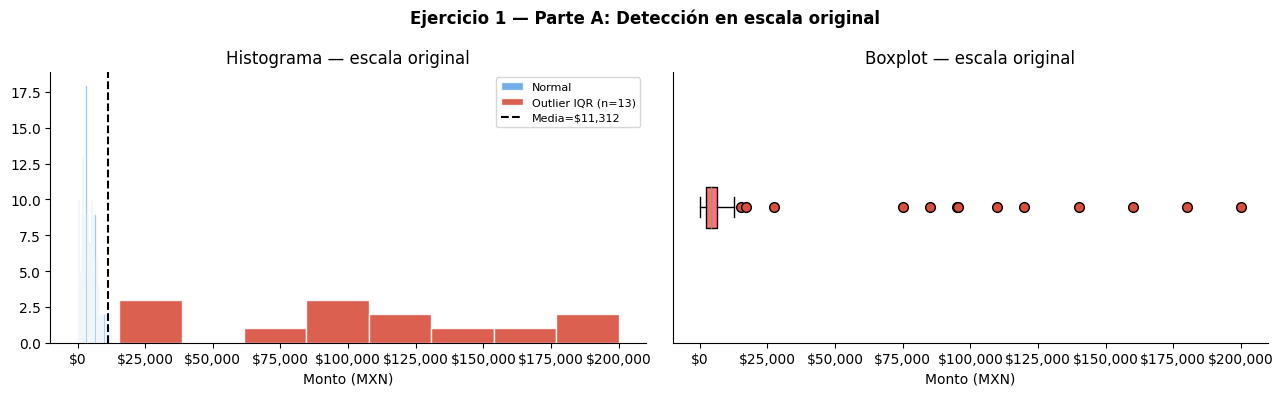


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [14]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?


In [15]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================
# -------------------------------------------------------------------
# PASO 1 — sucursales con frecuencia atipica

# 1. Agregar frecuencia por sucursal (media de días)
freq_sucursal = df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean()

print("="*50)
print("PASO 1:Frecuencia por sucursal")
print("="*50)
print(freq_sucursal)

# 2. IQR sobre las sucursales
Q1 = freq_sucursal.quantile(0.25)
Q3 = freq_sucursal.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

out_suc = (freq_sucursal < lim_inf) | (freq_sucursal > lim_sup)

print("SUCURSALES ATÍPICAS")
print(freq_sucursal)
print("\nOutliers por sucursal:")
print(out_suc)
print(f"\nSucursales atípicas: {list(freq_sucursal[out_suc].index)}")

# -------------------------------------------------------------------
# PASO 2 -  Aplica `√x` a días individuales y re-detecta outliers

# ============================================================
# PASO 2 — TRANSFORMACIÓN √x Y NUEVA DETECCIÓN DE OUTLIERS
# ============================================================

# 1. Transformación raíz cuadrada
df_vida_grupo['Dias_sqrt'] = np.sqrt(df_vida_grupo['Dias_Incapacidad'])

# 2. Aplicar IQR sobre la variable transformada
x = df_vida_grupo['Dias_sqrt']

Q1 = x.quantile(0.25)
Q3 = x.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Detección de outliers en escala transformada
out_sqrt = (x < lim_inf) | (x > lim_sup)

# (Opcional) outliers en escala original para comparación
x_orig = df_vida_grupo['Dias_Incapacidad']

Q1_o = x_orig.quantile(0.25)
Q3_o = x_orig.quantile(0.75)
IQR_o = Q3_o - Q1_o

lim_inf_o = Q1_o - 1.5 * IQR_o
lim_sup_o = Q3_o + 1.5 * IQR_o

out_orig = (x_orig < lim_inf_o) | (x_orig > lim_sup_o)

print("="*50)
print("PASO 2:Aplica `√x` a días individuales y re-detecta outliers")
print("="*50)

print(f"Outliers en escala original: {out_orig.sum()} ({out_orig.mean()*100:.2f}%)")
print(f"Outliers en √x: {out_sqrt.sum()} ({out_sqrt.mean()*100:.2f}%)")

print("\nLímites en escala √x:")
print(f"Inferior: {lim_inf:.3f}")
print(f"Superior: {lim_sup:.3f}")


# -------------------------------------------------------------------
# PASO 3 - TASA RELATIVA POR SUCURSAL

# Media de días por sucursal
x_bar = df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean()

# Normalización relativa
p_j = x_bar / x_bar.max()

print("="*50)
print("PASO 3 — TASA RELATIVA POR SUCURSAL")
print("="*50)

print("Media por sucursal:")
print(x_bar)

print("\nTasa relativa p_j:")
print(p_j)

print("\nSucursal más riesgosa (base 1.0):")
print(p_j.idxmax(), "→", p_j.max())

# ------------------------------------------------------------------------
# PASO 4 — arcsin(sqrt(p_j)) + IC 95%

import numpy as np
import pandas as pd

# Ya tenemos p_j del paso anterior
x_bar = df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].mean()
p_j = x_bar / x_bar.max()

# Tamaño por sucursal
n_j = df_vida_grupo.groupby('Sucursal').size()

# Transformación arcsin(sqrt(p_j))
theta_j = np.arcsin(np.sqrt(p_j))

# Varianza estabilizada
se_j = np.sqrt(1 / (4 * n_j))

# Intervalos de confianza
ic_inf = theta_j - 1.96 * se_j
ic_sup = theta_j + 1.96 * se_j

# Tabla resumen
resultados = pd.DataFrame({
    'p_j': p_j,
    'theta = arcsin(sqrt(p_j))': theta_j,
    'n_j': n_j,
    'IC_inf': ic_inf,
    'IC_sup': ic_sup
})

print("="*50)
print("PASO 4 — ARCSIN + IC 95%")
print("="*50)

print(resultados.sort_values('p_j', ascending=False))

# -----------------------------------------------------------------------------
# PASO 5 — CONCLUSIÓN FINAL

print("La sucursal atupica es la centro porque presenta tiene una frecuencia de días de incapacidad mucho mayor que el resto y en la transformación de arcsin se puede observar.")



Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0
PASO 1:Frecuencia por sucursal
Sucursal
Centro    12.406250
Este       5.000000
Norte      2.947368
Oeste      3.520000
Sur        4.400000
Name: Dias_Incapacidad, dtype: float64
SUCURSALES ATÍPICAS
Sucursal
Centro    12.406250
Este       5.000000
Norte      2.947368
Oeste      3.520000
Sur        4.400000
Name: Dias_Incapacidad, dtype: float64

Outliers por sucursal:
Sucursal
Centro     True
Este      False
Norte     False
Oeste     False
Sur       False
Name: Dias_Incapacidad, dtype: bool

Sucursales atípicas: ['Centro']
PAS

---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?


In [16]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar.describe().round(2))

# ============================================================
# TU CÓDIGO AQUÍ ↓
# ============================================================

# ============================================================
# PASO 1 — OUTLIERS EN ESCALA ORIGINAL
# ============================================================

def iqr_outliers(x):
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1

    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR

    return (x < lim_inf) | (x > lim_sup), lim_inf, lim_sup


# FRECUENCIA
out_freq, lim_inf_f, lim_sup_f = iqr_outliers(df_hogar['Num_Siniestros'])

# SEVERIDAD
out_sev, lim_inf_s, lim_sup_s = iqr_outliers(df_hogar['Monto_Promedio_MXN'])

print("="*60)
print("PASO 1 — OUTLIERS ESCALA ORIGINAL")
print("="*60)

print(f"Frecuencia → outliers: {out_freq.sum()} | sup: {lim_sup_f:.2f}")
print(f"Severidad  → outliers: {out_sev.sum()} | sup: {lim_sup_s:,.0f}")

# ============================================================
# PASO 2 — PRIMA PURA EN ESCENARIOS
# ============================================================

df = df_hogar.copy()

# escenarios frecuencia
freq_clean = df.loc[~out_freq, 'Num_Siniestros']
freq_wins  = df['Num_Siniestros'].clip(upper=lim_sup_f)

# escenarios severidad
sev_clean = df.loc[~out_sev, 'Monto_Promedio_MXN']
sev_wins  = df['Monto_Promedio_MXN'].clip(upper=lim_sup_s)

# primas
scenarios = pd.DataFrame({
    "Con outliers": [
        df['Costo_Total'].mean()
    ],
    "Sin outliers": [
        freq_clean.mean() * sev_clean.mean()
    ],
    "Winsorizado": [
        freq_wins.mean() * sev_wins.mean()
    ]
}, index=["Prima pura"])

print("="*60)
print("PASO 2 — PRIMA PURA")
print("="*60)

scenarios

# ============================================================
# PASO 3 — TRANSFORMACIONES
# ============================================================

df_hogar['freq_sqrt'] = np.sqrt(df_hogar['Num_Siniestros'])

ref_sev = df_hogar['Monto_Promedio_MXN'].median()
df_hogar['sev_arcsinh'] = np.arcsinh(df_hogar['Monto_Promedio_MXN'] / ref_sev)

print("="*60)
print("PASO 3 — TRANSFORMACIONES")
print("="*60)

print(f"Mediana severidad: {ref_sev:,.0f}")
print(df_hogar[['Num_Siniestros','freq_sqrt','Monto_Promedio_MXN','sev_arcsinh']].head())

# ============================================================
# PASO 4 — ASIMETRÍA Y CURTOSIS (ANTES vs DESPUÉS)
# ============================================================

from scipy.stats import kurtosis

# ============================================================
# ANTES (escala original)
# ============================================================

skew_freq_orig = df_hogar['Num_Siniestros'].skew()
kurt_freq_orig = kurtosis(df_hogar['Num_Siniestros'])

skew_sev_orig = df_hogar['Monto_Promedio_MXN'].skew()
kurt_sev_orig = kurtosis(df_hogar['Monto_Promedio_MXN'])

# ============================================================
# DESPUÉS (transformaciones)
# ============================================================

skew_freq_sqrt = df_hogar['freq_sqrt'].skew()
kurt_freq_sqrt = kurtosis(df_hogar['freq_sqrt'])

skew_sev_arc = df_hogar['sev_arcsinh'].skew()
kurt_sev_arc = kurtosis(df_hogar['sev_arcsinh'])

# ============================================================
# TABLA COMPARATIVA
# ============================================================

comparacion = pd.DataFrame({
    "Skewness Antes": [
        skew_freq_orig,
        skew_sev_orig
    ],
    "Skewness Después": [
        skew_freq_sqrt,
        skew_sev_arc
    ],
    "Kurtosis Antes": [
        kurt_freq_orig,
        kurt_sev_orig
    ],
    "Kurtosis Después": [
        kurt_freq_sqrt,
        kurt_sev_arc
    ]
}, index=[
    "Frecuencia",
    "Severidad"
])

print("="*70)
print("PASO 4 — COMPARACIÓN ANTES VS DESPUÉS")
print("="*70)

comparacion

# ============================================================
# PASO 5 — DOBLE OUTLIER
# ============================================================

out_freq_sqrt, _, _ = iqr_outliers(df_hogar['freq_sqrt'])
out_sev_arc, _, _ = iqr_outliers(df_hogar['sev_arcsinh'])

print("="*60)
print("PASO 5 — DOBLE OUTLIER")
print("="*60)

print(f"Freq original outliers: {out_freq.sum()}")
print(f"Freq sqrt outliers    : {out_freq_sqrt.sum()}")

print(f"Sev original outliers : {out_sev.sum()}")
print(f"Sev arcsinh outliers  : {out_sev_arc.sum()}")


# ============================================================
# PASO 6 — CONCLUSIÓN
# ============================================================

print("="*60)
print("PASO 5 — CONCLUSIÓN")
print("="*60)

print("No se puede usar para calcular la prima porque trabajar en escala transformada es útil para análisis, pero para la prima debe realizarse en la escala original o con corrección de sesgo.")



Dataset: 130 pólizas de hogar

Estadísticas:
       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00
PASO 1 — OUTLIERS ESCALA ORIGINAL
Frecuencia → outliers: 18 | sup: 3.50
Severidad  → outliers: 13 | sup: 21,496
PASO 2 — PRIMA PURA
PASO 3 — TRANSFORMACIONES
Mediana severidad: 8,425
   Num_Siniestros  freq_sqrt  Monto_Promedio_MXN  sev_arcsinh
0               0   0.000000            13080.87     1.223628
1               2   1.414214            12750.78     1